# 自动生成的 Notebook
这里写一些说明

In [1]:
def get_metadata_group(db_dict,group,group_name,group_field,use_group_field):
    if use_group_field:
        return pd.DataFrame([(item['sample_name'],item[group_field]) for item in db_dict[group] ], columns=['sample_name','group'])
    else:
        return pd.DataFrame([(item['sample_name'],item["re_groups_name"]) for item in db_dict[group] ], columns=['sample_name','group'])
def get_metadata(params,use_group_field=False,filter=None):
    group_field = params["group_field"]
    if filter is None:
        df_list = [get_metadata_group(params,group,group_name,group_field,use_group_field) for group,group_name in params["groups_name"].items()]
    else :
        df_list = [get_metadata_group(params,group,group_name,group_field,use_group_field) for group,group_name in params["groups_name"].items()
               if group in filter 
               ]
    metadata = pd.concat(df_list, ignore_index=True)
    metadata = metadata.set_index("sample_name")
    return metadata

In [2]:
import pandas as pd
from skbio.diversity import alpha_diversity
import matplotlib.pyplot as plt
import seaborn as sns
from skbio.diversity import beta_diversity
from skbio.stats.distance import permanova
from skbio.stats.ordination import pcoa
from matplotlib.patches import Ellipse
import numpy as np
from sklearn.preprocessing import LabelEncoder  
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats
from sklearn.model_selection import RepeatedStratifiedKFold

import sys
import os
import json
import pandas as pd 
import matplotlib.pyplot as plt
# script_dir = os.path.dirname(os.path.abspath(__file__))
common_dir =os.getenv("COMMON_SCRIPT_DIR")
sys.path.insert(0, common_dir)
from metaphlan import get_abundance
os.chdir(os.getenv("OUTPUT_DIR"))



params_path = sys.argv[1]
output_path = sys.argv[2]
params_path="params.json"
output_path="output"

with open(params_path) as f:
    data = json.load(f)

abundance0 = get_abundance(data)

metadata = get_metadata(data)

In [3]:
rank = data["rank"]
abundance_rank = abundance0.reset_index(['taxonomy','rank']).reset_index(drop=True).query("rank==@rank").drop("rank",axis=1)

abundance_rank= abundance_rank[~abundance_rank["taxonomy"].str.contains("GGB|SGB", regex=True)]
abundance_rank = abundance_rank.set_index("taxonomy").T

In [10]:
df_merge = pd.merge(abundance_rank,metadata,left_index=True,right_index=True)
df_merge

,Bifidobacterium pseudolongum,Corynebacterium stationis,Granulimonas faecalis,Leptogranulimonas caecicola,Coriobacteriaceae bacterium,Parvibacter caecicola,Adlercreutzia caecimuris,Adlercreutzia mucosicola,Adlercreutzia muris,Adlercreutzia sp DSM 108611,...,Pumilibacter sp CLA AA M10,Clostridium cocleatum,Erysipelotrichaceae bacterium,Erysipelotrichaceae bacterium NYU BL F16,Faecalibaculum rodentium,Erysipelotrichales bacterium,Turicibacter sp 1E2,Burkholderiaceae bacterium,Akkermansia muciniphila,group
ACC1,0.08779,0.00131,0.00000,0.05993,0.00411,0.000,0.00000,0.00011,0.00243,0.00000,...,0.00000,0.00000,0.08624,0.22601,0.00000,0.02099,0.04309,0.57022,0.00000,A
ACC2,0.02653,0.00000,0.00000,0.75263,0.01941,0.000,0.00420,0.00080,0.00297,0.00000,...,0.00600,0.06804,0.07089,0.18595,0.03613,0.03308,0.05053,0.00000,4.74579,A
ACC3,0.00000,0.00495,0.00000,0.00000,0.00467,0.000,0.00053,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.46549,0.00000,0.00000,0.21473,0.01787,0.00000,0.00000,A
ACC4,0.00000,0.00000,0.00000,0.01949,0.00175,0.000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00368,0.00000,0.00000,0.15578,0.07855,0.08457,0.24137,A
ACC5,0.02880,0.00000,0.00167,0.15097,0.00000,0.000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.02490,0.15445,0.08841,0.00000,0.06848,0.70383,3.21851,A
ACC6,0.04921,0.01298,0.00000,0.27609,0.00237,0.000,0.00000,0.00000,0.00806,0.00000,...,0.00000,0.02808,0.03140,0.02885,0.06968,0.00000,0.33789,0.22704,1.11315,B
ACC7,0.01371,0.00474,0.00000,0.05050,0.00000,0.000,0.00000,0.00000,0.00012,0.00000,...,0.00706,0.00388,0.00716,0.02206,0.03987,0.02848,0.07570,0.08395,0.81350,B
ACC8,0.18353,0.00000,0.03830,0.36761,0.03487,0.018,0.00746,0.01027,0.01593,0.00959,...,0.00000,0.00050,0.75148,0.09998,0.03007,0.63708,0.48816,0.08410,2.07596,B
ACC9,0.05538,0.00000,0.00913,0.14170,0.00078,0.000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00386,0.20496,0.02297,0.00998,0.00680,0.41498,0.28273,2.39028,B
ACC10,0.12894,0.00000,0.00448,0.12055,0.00090,0.000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.24478,0.02822,0.01520,0.01735,0.26033,0.57036,1.94271,B


In [14]:
df_merge.reset_index().to_csv("output/matrix.tsv",sep="\t",index=False)

In [5]:
# metadata

In [6]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from sklearn.decomposition import PCA
# from sklearn.preprocessing import StandardScaler

# # 假设 X 是样本 × 特征 的表格 (如 OTU/KO/Species abundance)
# # 假设 y 是分组标签（例如 "Healthy"/"Disease"）

# # 示例数据
# np.random.seed(42)
# X = np.random.rand(20, 10)    # 20个样本，10个特征
# y = ["GroupA"]*10 + ["GroupB"]*10
# X = df_merge.drop('group', axis=1)
# y = df_merge['group'].to_list()
# # 标准化（非常重要）
# X_scaled = StandardScaler().fit_transform(X)

# # PCA
# pca = PCA(n_components=2)
# pca_result = pca.fit_transform(X_scaled)

# # 转成DataFrame方便作图
# df_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'])
# df_pca['Group'] = y

# # 绘图
# plt.figure(figsize=(6,5))
# for group in df_pca['Group'].unique():
#     subset = df_pca[df_pca['Group'] == group]
#     plt.scatter(subset['PC1'], subset['PC2'], label=group, s=70)

# plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% var)")
# plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% var)")
# plt.legend()
# plt.title("PCA of Samples")
# plt.grid(alpha=0.3)
# plt.tight_layout()
# plt.show()


In [30]:
X = df_merge.drop('group', axis=1)
y = df_merge['group']

le = LabelEncoder()
y = le.fit_transform(y)  # HC→0, SCZ→1  
scaler = StandardScaler()
X = scaler.fit_transform(X)
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2']
}
clf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X, y)

cv = RepeatedStratifiedKFold(n_splits=3, n_repeats=20, random_state=42)

# cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
for train_idx, test_idx in cv.split(X, y):
    model = RandomForestClassifier(
        min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
        max_features=grid_search.best_params_['max_features'], 
        n_estimators=grid_search.best_params_['n_estimators'],   # 树的数量  
        criterion='gini',    # 分裂标准（基尼指数）  
        max_depth=grid_search.best_params_['max_depth'],        # 单棵树最大深度  
        min_samples_split=grid_search.best_params_['min_samples_split'],# 节点最小分裂样本数  
        random_state=42)
    model.fit(X[train_idx], y[train_idx])
    y_proba = model.predict_proba(X[test_idx])[:, 1]

    fpr, tpr, _ = roc_curve(y[test_idx], y_proba)
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)

    # 插值 TPR 到统一的 FPR 上
    tpr_interp = np.interp(mean_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs.append(tpr_interp)
# 转为 numpy 数组
tprs = np.array(tprs)
mean_tpr = tprs.mean(axis=0)
std_tpr = tprs.std(axis=0)
mean_auc = np.mean(aucs)
std_auc = np.std(aucs, ddof=1)
ci_low, ci_high = stats.norm.interval(0.95, loc=mean_auc, scale=std_auc / np.sqrt(len(aucs)))

# 置信区间带
tprs_upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)

In [32]:
# X_test.shape

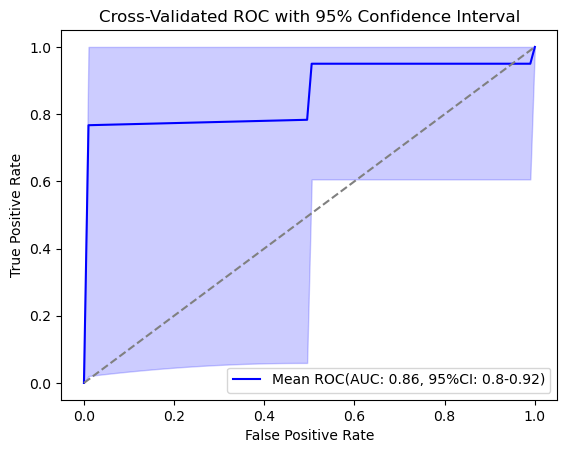

In [31]:
plt.figure()
plt.plot(mean_fpr, mean_tpr, color='blue', label=f'Mean ROC(AUC: {mean_auc:.2f}, 95%CI: {round(ci_low,2)}-{round(ci_high,2)})')
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='blue', alpha=0.2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validated ROC with 95% Confidence Interval')
plt.legend(loc='lower right')
plt.savefig("output/roc.pdf")